# Statistics for Machine Learning — Notebook 5  
# Statistical Thinking for Model Evaluation

## Why this notebook matters

Many students train a model and only print:

```python
accuracy_score(y_test, y_pred)
```

But a serious AI engineer asks deeper questions:

- Is the model overfitting?
- Is it underfitting?
- Is the test score reliable?
- Is the improvement real or random?
- Is the model calibrated?
- Which examples does the model fail on?
- Does performance change across groups?
- Will this model work on future data?
- Is the data distribution shifting?

This notebook teaches how to evaluate models statistically.

---

## What you will learn

1. Why model evaluation is statistical  
2. Train, validation, and test split  
3. Bias and variance intuition  
4. Underfitting and overfitting  
5. Learning curves  
6. Validation curves  
7. Cross-validation  
8. Metric uncertainty  
9. Bootstrap confidence intervals for metrics  
10. Model comparison using repeated splits  
11. Calibration and probability reliability  
12. Residual analysis for regression  
13. Error analysis for classification  
14. Slice-based evaluation  
15. Data drift and distribution shift  
16. Monitoring deployed model performance  
17. Mini project: model evaluation report

# 1. Model evaluation is not just one number

A model score is an estimate.

Example:

```text
Test accuracy = 0.86
```

This does not mean the model will always get exactly 86% accuracy in the real world.

The score depends on:

- the dataset sample
- train/test split
- class balance
- noise
- model randomness
- distribution shift
- evaluation metric
- threshold choice

So model evaluation is a statistical problem.

We need to evaluate both:

1. **Performance**
2. **Reliability of performance**

# 2. Setup

Run this cell first.

If something is missing:

```python
!pip install numpy pandas matplotlib seaborn scipy scikit-learn ipywidgets
```

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import norm, ttest_rel, ks_2samp

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    KFold,
    learning_curve,
    validation_curve,
    RepeatedStratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

try:
    import ipywidgets as widgets
    from ipywidgets import interact
    WIDGETS_AVAILABLE = True
except Exception:
    WIDGETS_AVAILABLE = False
    print("ipywidgets is not available. Install it using: pip install ipywidgets")

np.random.seed(42)

%matplotlib inline
sns.set_theme(style="whitegrid")

print("Setup complete.")

Setup complete.


# 3. Create a classification dataset

We will create a synthetic customer risk dataset.

Target:

- `0` = low risk
- `1` = high risk

We will use this dataset for classification evaluation.

In [2]:
X, y = make_classification(
    n_samples=3500,
    n_features=14,
    n_informative=8,
    n_redundant=3,
    n_classes=2,
    weights=[0.70, 0.30],
    class_sep=1.05,
    flip_y=0.04,
    random_state=42
)

feature_names = [
    "age_score",
    "income_score",
    "activity_score",
    "support_score",
    "usage_score",
    "payment_score",
    "engagement_score",
    "risk_score",
    "loyalty_score",
    "complaint_score",
    "discount_score",
    "region_score",
    "device_score",
    "history_score"
]

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

display(df.head())
display(df["target"].value_counts(normalize=True).round(3))

,age_score,income_score,activity_score,support_score,usage_score,payment_score,engagement_score,risk_score,loyalty_score,complaint_score,discount_score,region_score,device_score,history_score,target
0,-2.599563,-0.766990,3.234053,2.326573,0.241165,-0.040553,-1.529859,-1.103216,-1.139614,1.185358,-1.376792,2.160205,0.745354,-0.196271,0
1,0.544575,-0.121027,2.397989,2.400261,-0.169022,-0.540827,0.369591,-1.195881,-1.198836,3.104479,-0.875566,0.559138,0.216577,1.325236,0
2,-2.308282,0.489420,-0.782587,1.150328,0.577220,-0.119498,-2.692430,1.779934,2.534975,-0.016814,-0.193135,0.586402,1.348886,2.102836,0
3,4.678670,1.004676,-1.412912,-1.624716,-0.725103,-1.078331,4.802201,-1.413690,1.101033,3.009457,0.537938,-0.134300,-1.561020,2.999048,0
4,4.273329,-0.477230,-3.066567,-0.222230,-0.742846,0.972583,1.002029,-0.962097,-4.439590,-5.282023,-0.538993,-5.449716,0.586521,1.705577,1


target
0    0.689
1    0.311
Name: proportion, dtype: float64

# 4. Train, validation, and test split

A common mistake is using the test set again and again during model selection.

Correct idea:

## Training set
Used to train the model.

## Validation set
Used to tune model choices.

## Test set
Used only at the end for final evaluation.

If we tune using the test set, test performance becomes optimistic.

In [3]:
X = df[feature_names]
y = df["target"]

# First split: train+validation and test
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Second split: train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nTarget distribution:")
print("Train:", y_train.mean().round(3))
print("Validation:", y_val.mean().round(3))
print("Test:", y_test.mean().round(3))

Train shape: (2100, 14)
Validation shape: (700, 14)
Test shape: (700, 14)

Target distribution:
Train: 0.311
Validation: 0.31
Test: 0.311


# 5. Baseline model

Before using advanced models, always build a baseline.

A baseline gives a reference point.

For imbalanced classification, a naive baseline may predict the majority class only.

In [5]:
majority_class = y_train.mode()[0]
baseline_pred = np.full_like(y_val, fill_value=majority_class)

print("Majority class:", majority_class)
print("Baseline validation accuracy:", accuracy_score(y_val, baseline_pred))#.round(3))
print("Baseline validation F1:", f1_score(y_val, baseline_pred, zero_division=0))#.round(3))

Majority class: 0
Baseline validation accuracy: 0.69
Baseline validation F1: 0.0


# 6. Train multiple models

We will compare:

1. Logistic Regression  
2. Decision Tree  
3. Random Forest  
4. SVM  
5. Gradient Boosting  

Different models have different bias and variance behavior.

In [6]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=250, max_depth=8, random_state=42),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True, random_state=42))
    ]),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

val_rows = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_val)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, proba)
    else:
        auc = np.nan

    val_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_val, pred),
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
        "roc_auc": auc
    })

val_results = pd.DataFrame(val_rows).sort_values("f1", ascending=False)
display(val_results.round(3))

,model,accuracy,precision,recall,f1,roc_auc
3,SVM,0.906,0.899,0.783,0.837,0.952
4,Gradient Boosting,0.877,0.832,0.756,0.792,0.934
2,Random Forest,0.864,0.851,0.682,0.757,0.940
1,Decision Tree,0.801,0.719,0.590,0.648,0.827
0,Logistic Regression,0.741,0.618,0.433,0.509,0.803


# 7. Visual model comparison

Tables are useful, but charts make comparison easier.

Notice that the best model depends on the metric.

For example:

- fraud detection may care more about recall
- spam detection may care more about precision
- balanced problems may care about F1
- probability ranking may care about ROC AUC

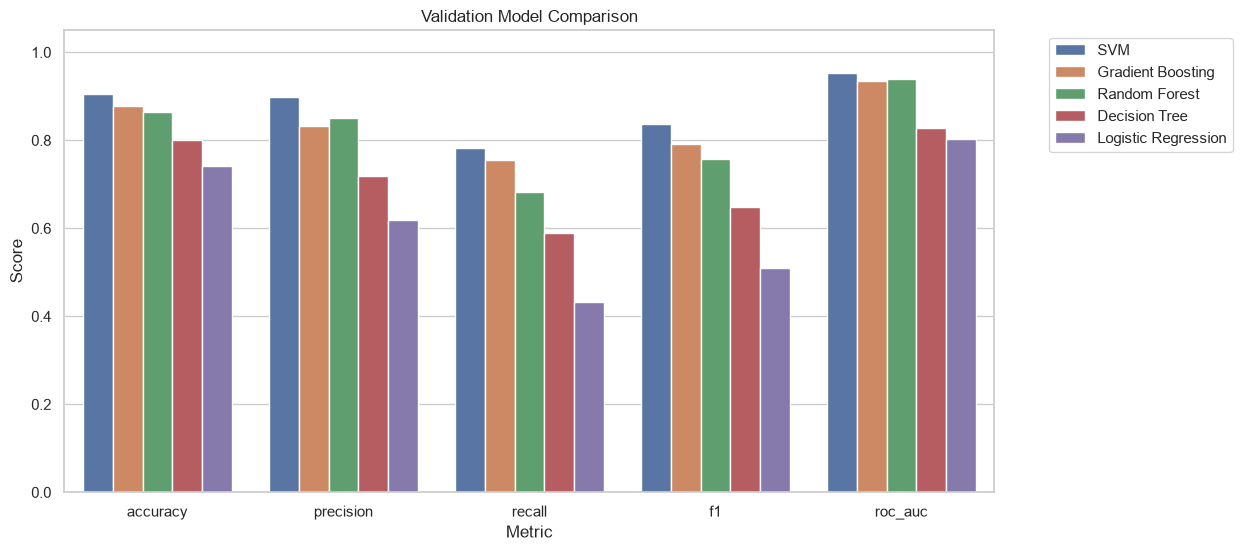

In [7]:
val_long = val_results.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=val_long, x="metric", y="score", hue="model")
plt.title("Validation Model Comparison")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

# 8. Bias and variance intuition

## Bias

Bias means the model is too simple and misses the true pattern.

High bias often causes underfitting.

Symptoms:

- low train score
- low validation score

## Variance

Variance means the model is too sensitive to training data.

High variance often causes overfitting.

Symptoms:

- high train score
- low validation score

---

## Goal

Find a model with good balance:

- train score high enough
- validation score also high
- gap between train and validation not too large

# 9. Underfitting and overfitting with decision trees

A decision tree with very small depth may underfit.  
A decision tree with very large depth may overfit.

Let's test different depths.

,max_depth,train_f1,val_f1,train_accuracy,val_accuracy
0,1,0.398,0.377,0.741,0.726
1,2,0.412,0.384,0.758,0.743
2,3,0.589,0.523,0.792,0.760
3,4,0.636,0.508,0.809,0.746
4,5,0.710,0.550,0.843,0.769
5,6,0.803,0.648,0.884,0.801
6,7,0.827,0.650,0.902,0.804
7,8,0.880,0.708,0.926,0.824
8,9,0.919,0.690,0.950,0.813
9,10,0.952,0.680,0.970,0.810


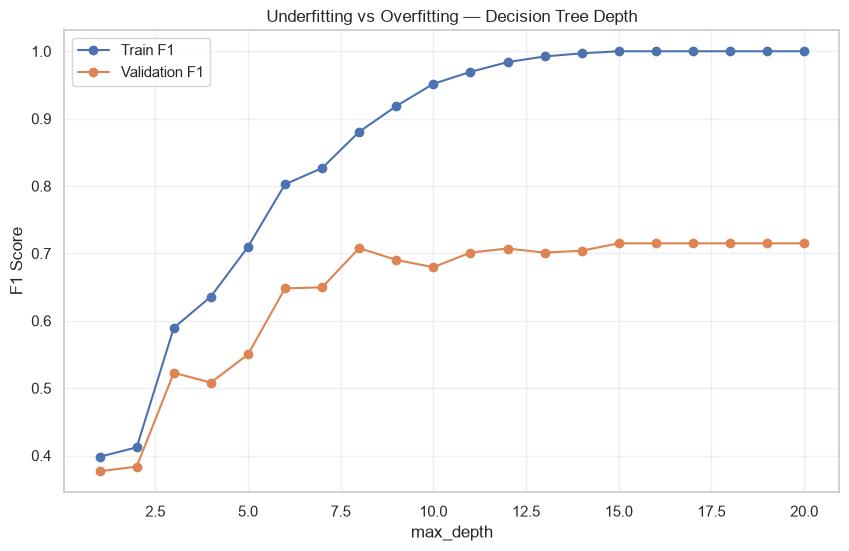

In [8]:
depths = list(range(1, 21))

tree_rows = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)

    train_pred = tree.predict(X_train)
    val_pred = tree.predict(X_val)

    tree_rows.append({
        "max_depth": depth,
        "train_f1": f1_score(y_train, train_pred),
        "val_f1": f1_score(y_val, val_pred),
        "train_accuracy": accuracy_score(y_train, train_pred),
        "val_accuracy": accuracy_score(y_val, val_pred)
    })

tree_df = pd.DataFrame(tree_rows)

display(tree_df.round(3))

plt.figure(figsize=(10, 6))
plt.plot(tree_df["max_depth"], tree_df["train_f1"], marker="o", label="Train F1")
plt.plot(tree_df["max_depth"], tree_df["val_f1"], marker="o", label="Validation F1")
plt.title("Underfitting vs Overfitting — Decision Tree Depth")
plt.xlabel("max_depth")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 10. Learning curve

A learning curve shows how model performance changes as training size increases.

It answers:

- Do we need more data?
- Is the model overfitting?
- Is the model underfitting?

Typical patterns:

## High train score, low validation score
High variance / overfitting.

## Low train score, low validation score
High bias / underfitting.

## Both improve with more data
More data may help.

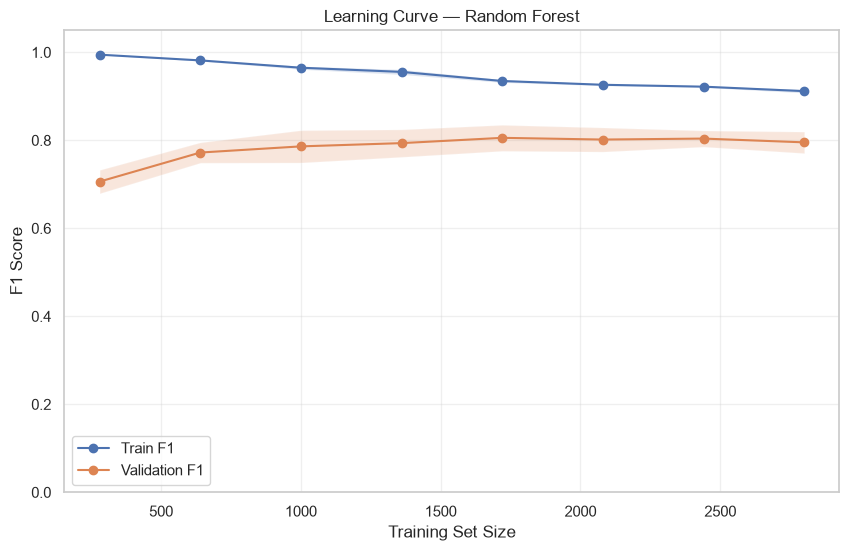

In [9]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    rf_model,
    X,
    y,
    cv=5,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=None
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))

plt.plot(train_sizes, train_mean, marker="o", label="Train F1")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)

plt.plot(train_sizes, val_mean, marker="o", label="Validation F1")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Learning Curve — Random Forest")
plt.xlabel("Training Set Size")
plt.ylabel("F1 Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 11. Validation curve

A validation curve tests one hyperparameter.

Here we test Random Forest `max_depth`.

This helps find the point where the model becomes too simple or too complex.

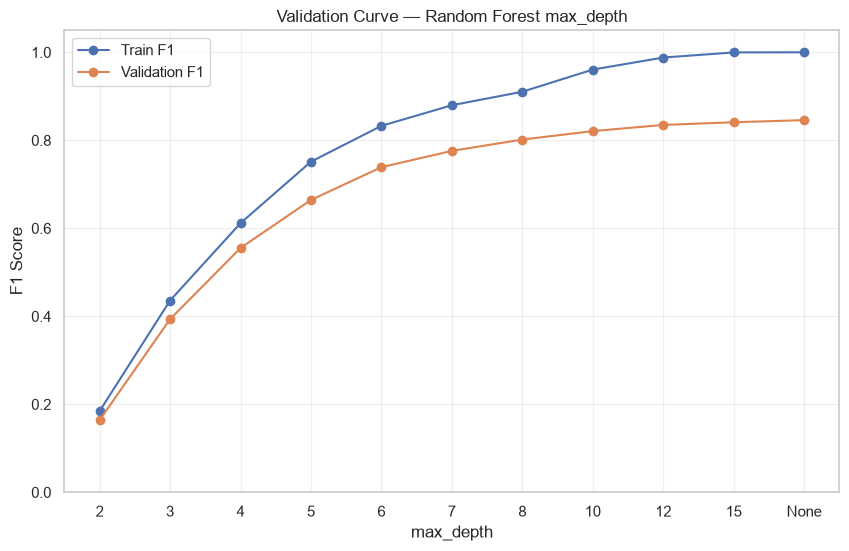

In [11]:
param_range = [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, None]

train_scores, val_scores = validation_curve(
    RandomForestClassifier(n_estimators=150, random_state=42),
    X,
    y,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="f1"
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

x_labels = [str(v) for v in param_range]

plt.figure(figsize=(10, 6))
plt.plot(x_labels, train_mean, marker="o", label="Train F1")
plt.plot(x_labels, val_mean, marker="o", label="Validation F1")
plt.title("Validation Curve — Random Forest max_depth")
plt.xlabel("max_depth")
plt.ylabel("F1 Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 12. Why cross-validation?

A single train/test split can be lucky or unlucky.

Cross-validation gives a more stable estimate.

In k-fold cross-validation:

1. Split data into k folds
2. Train on k-1 folds
3. Validate on remaining fold
4. Repeat k times
5. Average scores

This gives performance distribution, not only one score.

In [12]:
cv = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)

cv_rows = []

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="f1")

    cv_rows.append({
        "model": name,
        "mean_f1": scores.mean(),
        "std_f1": scores.std(),
        "min_f1": scores.min(),
        "max_f1": scores.max()
    })

cv_results = pd.DataFrame(cv_rows).sort_values("mean_f1", ascending=False)
display(cv_results.round(3))

,model,mean_f1,std_f1,min_f1,max_f1
3,SVM,0.884,0.011,0.864,0.898
2,Random Forest,0.804,0.028,0.753,0.843
4,Gradient Boosting,0.798,0.027,0.764,0.850
1,Decision Tree,0.650,0.057,0.557,0.735
0,Logistic Regression,0.569,0.031,0.527,0.615


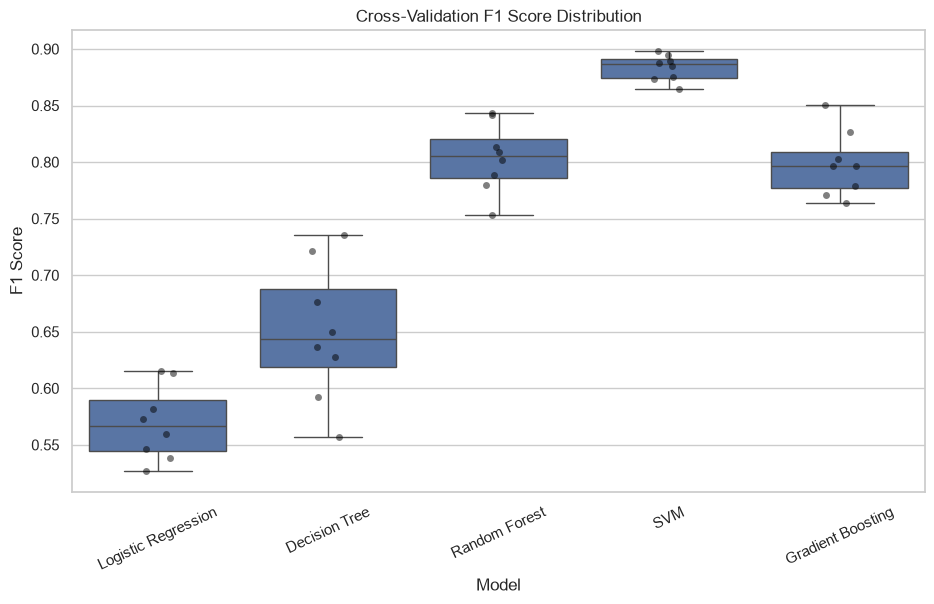

In [13]:
# Visualize fold score distributions

fold_score_rows = []

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="f1")
    for fold_id, score in enumerate(scores, start=1):
        fold_score_rows.append({
            "model": name,
            "fold": fold_id,
            "f1_score": score
        })

fold_scores_df = pd.DataFrame(fold_score_rows)

plt.figure(figsize=(11, 6))
sns.boxplot(data=fold_scores_df, x="model", y="f1_score")
sns.stripplot(data=fold_scores_df, x="model", y="f1_score", color="black", alpha=0.5)
plt.title("Cross-Validation F1 Score Distribution")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=25)
plt.show()

# 13. Metric uncertainty

A metric calculated on a finite test set has uncertainty.

Example:

```text
accuracy = 0.86
```

If the test set is small, the uncertainty is larger.

Accuracy is a proportion, so we can calculate an approximate confidence interval.

In [ ]:
best_model_name = cv_results.iloc[0]["model"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)
test_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred)

n_test = len(y_test)

z = norm.ppf(0.975)
se_acc = np.sqrt(test_accuracy * (1 - test_accuracy) / n_test)

acc_ci_lower = test_accuracy - z * se_acc
acc_ci_upper = test_accuracy + z * se_acc

print("Best model:", best_model_name)
print("Test accuracy:", round(test_accuracy, 3))
print("95% CI for accuracy:", (round(acc_ci_lower, 3), round(acc_ci_upper, 3)))
print("Test F1:", round(test_f1, 3))

# 14. Bootstrap confidence interval for F1

F1-score does not have a simple confidence interval formula.

We can use bootstrap:

1. Resample the test predictions with replacement
2. Calculate F1 for each bootstrap sample
3. Use 2.5th and 97.5th percentiles

In [ ]:
def bootstrap_metric_ci(y_true, y_pred, metric_func, n_bootstrap=2000, confidence=0.95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    n = len(y_true)

    scores = []

    for _ in range(n_bootstrap):
        idx = np.random.choice(np.arange(n), size=n, replace=True)
        score = metric_func(y_true[idx], y_pred[idx])
        scores.append(score)

    lower = np.percentile(scores, (1 - confidence) / 2 * 100)
    upper = np.percentile(scores, (1 + confidence) / 2 * 100)

    return np.array(scores), lower, upper

bootstrap_f1_scores, f1_lower, f1_upper = bootstrap_metric_ci(
    y_test,
    test_pred,
    lambda yt, yp: f1_score(yt, yp, zero_division=0)
)

print("Observed F1:", round(test_f1, 3))
print("Bootstrap 95% CI for F1:", (round(f1_lower, 3), round(f1_upper, 3)))

plt.figure(figsize=(9, 5))
sns.histplot(bootstrap_f1_scores, bins=40, kde=True)
plt.axvline(f1_lower, linestyle="--", label="2.5 percentile")
plt.axvline(f1_upper, linestyle="--", label="97.5 percentile")
plt.axvline(test_f1, linestyle="-", label="Observed F1")
plt.title("Bootstrap Distribution of F1 Score")
plt.xlabel("F1 Score")
plt.legend()
plt.show()

# 15. Repeated train-test splits

Another way to understand metric stability:

Repeat train/test splitting many times.

If model performance changes a lot across splits, the model estimate is unstable.

In [ ]:
split_rows = []

for seed in range(30):
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=seed,
        stratify=y
    )

    model = RandomForestClassifier(n_estimators=150, max_depth=8, random_state=seed)
    model.fit(X_train_s, y_train_s)
    pred_s = model.predict(X_test_s)

    split_rows.append({
        "seed": seed,
        "accuracy": accuracy_score(y_test_s, pred_s),
        "f1": f1_score(y_test_s, pred_s),
        "precision": precision_score(y_test_s, pred_s, zero_division=0),
        "recall": recall_score(y_test_s, pred_s, zero_division=0)
    })

split_df = pd.DataFrame(split_rows)

display(split_df.describe().round(3))

plt.figure(figsize=(10, 5))
sns.histplot(split_df["f1"], bins=12, kde=True)
plt.title("F1 Distribution Across Repeated Train-Test Splits")
plt.xlabel("F1 Score")
plt.show()

# 16. Statistical comparison of two models

If two models are evaluated on the same cross-validation folds, the scores are paired.

We can compare paired fold scores.

Important:

This is a useful learning method, but real ML statistical comparison can be more complex.

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

lr_scores = cross_val_score(models["Logistic Regression"], X, y, cv=cv, scoring="f1")
rf_scores = cross_val_score(models["Random Forest"], X, y, cv=cv, scoring="f1")

comparison_df = pd.DataFrame({
    "fold": np.arange(1, 11),
    "logistic_regression_f1": lr_scores,
    "random_forest_f1": rf_scores,
    "difference_rf_minus_lr": rf_scores - lr_scores
})

display(comparison_df.round(3))

t_stat, p_value = ttest_rel(rf_scores, lr_scores)

print("Mean Logistic Regression F1:", round(lr_scores.mean(), 3))
print("Mean Random Forest F1:", round(rf_scores.mean(), 3))
print("Mean difference:", round((rf_scores - lr_scores).mean(), 3))
print("Paired t-test p-value:", round(p_value, 5))

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(comparison_df["fold"], comparison_df["logistic_regression_f1"], marker="o", label="Logistic Regression")
plt.plot(comparison_df["fold"], comparison_df["random_forest_f1"], marker="o", label="Random Forest")
plt.title("Paired Cross-Validation Fold Scores")
plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(comparison_df["difference_rf_minus_lr"], bins=8, kde=True)
plt.axvline(0, linestyle="--", label="No difference")
plt.title("Distribution of Paired Fold Differences")
plt.xlabel("RF F1 - LR F1")
plt.legend()
plt.show()

# 17. Confusion matrix and error types

A confusion matrix helps show model mistakes.

For binary classification:

- True Negative: actual 0, predicted 0
- False Positive: actual 0, predicted 1
- False Negative: actual 1, predicted 0
- True Positive: actual 1, predicted 1

The best metric depends on the cost of errors.

Example:

- Fraud detection: false negatives may be very costly
- Spam detection: false positives may annoy users

In [ ]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Actual 0", "Actual 1"]
)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, test_pred, zero_division=0))

# 18. Threshold analysis

Many classifiers output probabilities.

Default threshold is usually 0.5.

But the best threshold depends on the problem.

Lower threshold:

- more positive predictions
- higher recall
- lower precision

Higher threshold:

- fewer positive predictions
- higher precision
- lower recall

In [ ]:
test_proba = best_model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.05, 0.95, 19)

threshold_rows = []

for threshold in thresholds:
    pred_t = (test_proba >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, pred_t),
        "precision": precision_score(y_test, pred_t, zero_division=0),
        "recall": recall_score(y_test, pred_t, zero_division=0),
        "f1": f1_score(y_test, pred_t, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)

display(threshold_df.round(3))

plt.figure(figsize=(10, 6))
plt.plot(threshold_df["threshold"], threshold_df["accuracy"], marker="o", label="Accuracy")
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.title("Metric Behavior Across Thresholds")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 19. Interactive threshold dashboard

Use the slider to see how threshold changes the confusion matrix and metrics.

In [ ]:
def threshold_dashboard(threshold=0.5):
    pred_t = (test_proba >= threshold).astype(int)
    cm_t = confusion_matrix(y_test, pred_t)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm_t,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["Actual 0", "Actual 1"],
        ax=ax
    )

    ax.set_title(f"Confusion Matrix at Threshold {threshold:.2f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.show()

    print(f"Accuracy:  {accuracy_score(y_test, pred_t):.3f}")
    print(f"Precision: {precision_score(y_test, pred_t, zero_division=0):.3f}")
    print(f"Recall:    {recall_score(y_test, pred_t, zero_division=0):.3f}")
    print(f"F1-score:  {f1_score(y_test, pred_t, zero_division=0):.3f}")

if WIDGETS_AVAILABLE:
    interact(
        threshold_dashboard,
        threshold=widgets.FloatSlider(value=0.5, min=0.05, max=0.95, step=0.05)
    )
else:
    threshold_dashboard(0.5)

# 20. Calibration

A model is calibrated if predicted probabilities match real frequencies.

Example:

If 100 customers are predicted with 70% risk, about 70 should actually be positive.

Calibration matters when probabilities are used for decisions.

Examples:

- medical risk
- credit risk
- churn retention offers
- fraud investigation priority

In [ ]:
prob_true, prob_pred = calibration_curve(y_test, test_proba, n_bins=10, strategy="uniform")

plt.figure(figsize=(7, 6))
plt.plot(prob_pred, prob_true, marker="o", label=best_model_name)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
plt.title("Calibration Curve")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Actual Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

brier = brier_score_loss(y_test, test_proba)
print("Brier score:", round(brier, 4))

# 21. Calibrating a model

Some models give probabilities that are not well calibrated.

We can use calibration methods like:

- sigmoid calibration
- isotonic calibration

Here we calibrate a Random Forest.

In [14]:
base_rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)

calibrated_rf = CalibratedClassifierCV(
    estimator=base_rf,
    method="sigmoid",
    cv=5
)

calibrated_rf.fit(X_train, y_train)

calibrated_proba = calibrated_rf.predict_proba(X_test)[:, 1]

prob_true_base, prob_pred_base = calibration_curve(y_test, test_proba, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test, calibrated_proba, n_bins=10)

plt.figure(figsize=(7, 6))
plt.plot(prob_pred_base, prob_true_base, marker="o", label="Before Calibration")
plt.plot(prob_pred_cal, prob_true_cal, marker="o", label="After Calibration")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
plt.title("Calibration Before vs After")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Actual Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Brier before:", round(brier_score_loss(y_test, test_proba), 4))
print("Brier after:", round(brier_score_loss(y_test, calibrated_proba), 4))

NameError: name 'test_proba' is not defined

# 22. Error analysis

Error analysis means studying where the model fails.

We can compare:

- correct predictions
- false positives
- false negatives

This helps improve features, data, model, or threshold.

In [ ]:
error_df = X_test.copy()
error_df["actual"] = y_test.values
error_df["predicted"] = test_pred
error_df["probability"] = test_proba

def error_type(row):
    if row["actual"] == 1 and row["predicted"] == 1:
        return "True Positive"
    if row["actual"] == 0 and row["predicted"] == 0:
        return "True Negative"
    if row["actual"] == 0 and row["predicted"] == 1:
        return "False Positive"
    if row["actual"] == 1 and row["predicted"] == 0:
        return "False Negative"

error_df["error_type"] = error_df.apply(error_type, axis=1)

display(error_df["error_type"].value_counts())

plt.figure(figsize=(9, 5))
sns.countplot(data=error_df, x="error_type")
plt.title("Prediction Outcome Types")
plt.xlabel("Outcome Type")
plt.ylabel("Count")
plt.xticks(rotation=25)
plt.show()

In [ ]:
# Compare feature distributions by error type

important_features = ["risk_score", "support_score", "engagement_score", "complaint_score"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, col in zip(axes.ravel(), important_features):
    sns.boxplot(data=error_df, x="error_type", y=col, ax=ax)
    ax.set_title(f"{col} by Error Type")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# 23. Slice-based evaluation

A model may perform well overall but fail for a subgroup.

This is called slice-based evaluation.

Examples:

- region
- age group
- customer segment
- device type
- language
- product category
- income group

In responsible AI and production ML, slice performance is very important.

In [ ]:
# Create artificial groups from features for slice evaluation

slice_df = error_df.copy()

slice_df["risk_group"] = pd.qcut(slice_df["risk_score"], q=4, labels=["Low", "Medium", "High", "Very High"])
slice_df["support_group"] = pd.qcut(slice_df["support_score"], q=4, labels=["Low", "Medium", "High", "Very High"])

slice_rows = []

for group_name, group_data in slice_df.groupby("risk_group"):
    slice_rows.append({
        "slice": f"risk_group={group_name}",
        "count": len(group_data),
        "accuracy": accuracy_score(group_data["actual"], group_data["predicted"]),
        "precision": precision_score(group_data["actual"], group_data["predicted"], zero_division=0),
        "recall": recall_score(group_data["actual"], group_data["predicted"], zero_division=0),
        "f1": f1_score(group_data["actual"], group_data["predicted"], zero_division=0)
    })

slice_results = pd.DataFrame(slice_rows)

display(slice_results.round(3))

plt.figure(figsize=(9, 5))
sns.barplot(data=slice_results, x="slice", y="f1")
plt.title("F1 Score by Risk Group")
plt.xlabel("Slice")
plt.ylabel("F1 Score")
plt.xticks(rotation=25)
plt.ylim(0, 1)
plt.show()

# 24. Regression evaluation dataset

Now we create a regression dataset.

Regression model evaluation uses different metrics:

- MAE
- MSE
- RMSE
- R²
- residual plots

Residual analysis is very important.

In [ ]:
X_reg, y_reg = make_regression(
    n_samples=2200,
    n_features=8,
    n_informative=6,
    noise=25,
    random_state=42
)

# Add non-linearity and heteroscedasticity
y_reg = y_reg + 0.03 * (X_reg[:, 0] ** 2) * 100 + np.random.normal(0, np.abs(X_reg[:, 1]) * 10, size=len(y_reg))

reg_feature_names = [f"feature_{i}" for i in range(X_reg.shape[1])]

reg_df = pd.DataFrame(X_reg, columns=reg_feature_names)
reg_df["target"] = y_reg

display(reg_df.head())

# 25. Train regression models

We compare Linear Regression, Ridge, and Random Forest Regressor.

In [ ]:
Xr = reg_df[reg_feature_names]
yr = reg_df["target"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr,
    yr,
    test_size=0.25,
    random_state=42
)

reg_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
}

reg_rows = []

for name, model in reg_models.items():
    model.fit(Xr_train, yr_train)
    pred = model.predict(Xr_test)

    mse = mean_squared_error(yr_test, pred)
    rmse = np.sqrt(mse)

    reg_rows.append({
        "model": name,
        "mae": mean_absolute_error(yr_test, pred),
        "rmse": rmse,
        "r2": r2_score(yr_test, pred)
    })

reg_results = pd.DataFrame(reg_rows).sort_values("rmse")
display(reg_results.round(3))

# 26. Residual analysis

Residual means:

```text
residual = actual - predicted
```

A good regression model should have residuals:

- centered around 0
- no clear pattern against predictions
- roughly stable spread
- not too many extreme outliers

In [ ]:
best_reg_name = reg_results.iloc[0]["model"]
best_reg_model = reg_models[best_reg_name]

reg_pred = best_reg_model.predict(Xr_test)
residuals = yr_test.values - reg_pred

residual_df = pd.DataFrame({
    "actual": yr_test.values,
    "predicted": reg_pred,
    "residual": residuals
})

display(residual_df.head())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=residual_df, x="predicted", y="residual", alpha=0.6, ax=axes[0])
axes[0].axhline(0, linestyle="--")
axes[0].set_title("Residuals vs Predicted Values")

sns.histplot(residual_df["residual"], bins=40, kde=True, ax=axes[1])
axes[1].axvline(0, linestyle="--")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

# 27. Actual vs predicted plot

This plot shows how close predictions are to true values.

Perfect predictions would lie on the diagonal line.

In [ ]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=residual_df, x="actual", y="predicted", alpha=0.6)

min_val = min(residual_df["actual"].min(), residual_df["predicted"].min())
max_val = max(residual_df["actual"].max(), residual_df["predicted"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title(f"Actual vs Predicted — {best_reg_name}")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True, alpha=0.3)
plt.show()

# 28. Bootstrap confidence interval for RMSE

Regression metrics also have uncertainty.

We can bootstrap RMSE.

In [ ]:
def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

bootstrap_rmse = []

yr_test_array = yr_test.values
reg_pred_array = np.array(reg_pred)
n = len(yr_test_array)

for _ in range(2000):
    idx = np.random.choice(np.arange(n), size=n, replace=True)
    bootstrap_rmse.append(rmse_score(yr_test_array[idx], reg_pred_array[idx]))

rmse_observed = rmse_score(yr_test_array, reg_pred_array)
rmse_lower = np.percentile(bootstrap_rmse, 2.5)
rmse_upper = np.percentile(bootstrap_rmse, 97.5)

print("Observed RMSE:", round(rmse_observed, 3))
print("Bootstrap 95% CI for RMSE:", (round(rmse_lower, 3), round(rmse_upper, 3)))

plt.figure(figsize=(9, 5))
sns.histplot(bootstrap_rmse, bins=40, kde=True)
plt.axvline(rmse_lower, linestyle="--", label="2.5 percentile")
plt.axvline(rmse_upper, linestyle="--", label="97.5 percentile")
plt.axvline(rmse_observed, linestyle="-", label="Observed RMSE")
plt.title("Bootstrap Distribution of RMSE")
plt.xlabel("RMSE")
plt.legend()
plt.show()

# 29. Data drift and distribution shift

A model trained on one distribution may fail when future data changes.

This is called data drift or distribution shift.

Examples:

- customer behavior changes
- new market region
- seasonal effects
- new product launched
- sensor calibration changes
- fraud strategy changes
- language usage changes

We must monitor input feature distributions and model performance over time.

In [ ]:
# Simulate training feature and future feature with drift

train_feature = np.random.normal(loc=0, scale=1, size=2000)
future_feature_no_drift = np.random.normal(loc=0, scale=1, size=2000)
future_feature_drift = np.random.normal(loc=0.7, scale=1.2, size=2000)

plt.figure(figsize=(10, 5))
sns.kdeplot(train_feature, label="Training Distribution", fill=True, alpha=0.3)
sns.kdeplot(future_feature_no_drift, label="Future No Drift", fill=True, alpha=0.3)
sns.kdeplot(future_feature_drift, label="Future With Drift", fill=True, alpha=0.3)
plt.title("Feature Distribution Drift")
plt.xlabel("Feature Value")
plt.legend()
plt.show()

# 30. Kolmogorov-Smirnov test for drift

The KS test compares two distributions.

Hypotheses:

```text
H0: distributions are the same
H1: distributions are different
```

Small p-value suggests distribution shift.

Important:

With very large data, tiny differences can become statistically significant.  
Always combine test results with visual inspection and practical impact.

In [ ]:
ks_no_drift = ks_2samp(train_feature, future_feature_no_drift)
ks_drift = ks_2samp(train_feature, future_feature_drift)

print("No drift KS statistic:", round(ks_no_drift.statistic, 4), "p-value:", round(ks_no_drift.pvalue, 5))
print("Drift KS statistic:", round(ks_drift.statistic, 4), "p-value:", round(ks_drift.pvalue, 5))

# 31. Population Stability Index PSI

PSI is a common drift monitoring metric.

Interpretation rule of thumb:

- PSI < 0.10: little or no shift
- 0.10 to 0.25: moderate shift
- > 0.25: significant shift

PSI compares distribution bins between expected data and actual data.

In [ ]:
def calculate_psi(expected, actual, bins=10):
    expected = np.array(expected)
    actual = np.array(actual)

    breakpoints = np.percentile(expected, np.linspace(0, 100, bins + 1))
    breakpoints = np.unique(breakpoints)

    expected_counts, _ = np.histogram(expected, bins=breakpoints)
    actual_counts, _ = np.histogram(actual, bins=breakpoints)

    expected_perc = expected_counts / expected_counts.sum()
    actual_perc = actual_counts / actual_counts.sum()

    # avoid division by zero
    expected_perc = np.where(expected_perc == 0, 0.0001, expected_perc)
    actual_perc = np.where(actual_perc == 0, 0.0001, actual_perc)

    psi_values = (actual_perc - expected_perc) * np.log(actual_perc / expected_perc)
    psi = np.sum(psi_values)

    return psi

psi_no_drift = calculate_psi(train_feature, future_feature_no_drift)
psi_drift = calculate_psi(train_feature, future_feature_drift)

print("PSI no drift:", round(psi_no_drift, 4))
print("PSI drift:", round(psi_drift, 4))

# 32. Monitoring model performance over time

In production, performance can change over time.

We simulate monthly model F1 scores.

Then we detect whether performance is dropping.

In [ ]:
months = pd.date_range("2026-01-01", periods=12, freq="M").strftime("%b")

monthly_f1 = np.array([0.76, 0.75, 0.77, 0.74, 0.75, 0.73, 0.71, 0.70, 0.68, 0.66, 0.64, 0.62])
monthly_volume = np.random.randint(800, 1500, size=12)

monitor_df = pd.DataFrame({
    "month": months,
    "f1_score": monthly_f1,
    "prediction_volume": monthly_volume
})

monitor_df["rolling_f1"] = monitor_df["f1_score"].rolling(3).mean()

display(monitor_df)

plt.figure(figsize=(10, 5))
plt.plot(monitor_df["month"], monitor_df["f1_score"], marker="o", label="Monthly F1")
plt.plot(monitor_df["month"], monitor_df["rolling_f1"], marker="o", label="3-Month Rolling F1")
plt.axhline(0.70, linestyle="--", label="Alert threshold")
plt.title("Model Performance Monitoring Over Time")
plt.xlabel("Month")
plt.ylabel("F1 Score")
plt.ylim(0.55, 0.82)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 33. Statistical monitoring alerts

A simple monitoring rule:

- alert if F1 drops below threshold
- alert if rolling average drops
- alert if prediction volume changes strongly
- alert if feature distribution drifts

In [ ]:
monitor_df["f1_alert"] = monitor_df["f1_score"] < 0.70
monitor_df["rolling_alert"] = monitor_df["rolling_f1"] < 0.70
monitor_df["volume_change_pct"] = monitor_df["prediction_volume"].pct_change() * 100
monitor_df["volume_alert"] = monitor_df["volume_change_pct"].abs() > 25

display(monitor_df)

print("F1 alert months:")
display(monitor_df.loc[monitor_df["f1_alert"], ["month", "f1_score"]])

print("Rolling F1 alert months:")
display(monitor_df.loc[monitor_df["rolling_alert"], ["month", "rolling_f1"]])

# 34. Interactive bias-variance demo

Change decision tree depth.

Observe how train and validation scores change.

In [ ]:
def bias_variance_tree_demo(max_depth=3):
    tree = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    tree.fit(X_train, y_train)

    train_pred = tree.predict(X_train)
    val_pred = tree.predict(X_val)

    train_f1 = f1_score(y_train, train_pred)
    val_f1 = f1_score(y_val, val_pred)

    cm_val = confusion_matrix(y_val, val_pred)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sns.heatmap(
        cm_val,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["Actual 0", "Actual 1"],
        ax=axes[0]
    )
    axes[0].set_title("Validation Confusion Matrix")

    scores = pd.DataFrame({
        "set": ["Train", "Validation"],
        "f1": [train_f1, val_f1]
    })
    sns.barplot(data=scores, x="set", y="f1", ax=axes[1])
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Train vs Validation F1")

    plt.tight_layout()
    plt.show()

    print("max_depth:", max_depth)
    print("Train F1:", round(train_f1, 3))
    print("Validation F1:", round(val_f1, 3))
    print("Gap:", round(train_f1 - val_f1, 3))

    if train_f1 < 0.5 and val_f1 < 0.5:
        print("Likely underfitting.")
    elif train_f1 - val_f1 > 0.15:
        print("Likely overfitting.")
    else:
        print("Model complexity looks more balanced.")

if WIDGETS_AVAILABLE:
    interact(
        bias_variance_tree_demo,
        max_depth=widgets.IntSlider(value=3, min=1, max=25, step=1)
    )
else:
    bias_variance_tree_demo(3)

# 35. Model evaluation checklist

Use this checklist for serious ML evaluation.

## Data split
- Was test set kept untouched?
- Is split stratified for classification?
- Is time order respected if time-series?

## Metrics
- Is the metric aligned with business cost?
- Are precision and recall both checked?
- Is threshold selected carefully?

## Stability
- Is cross-validation used?
- Are scores stable across folds?
- Are confidence intervals calculated?

## Errors
- Are false positives and false negatives studied?
- Are hard examples analyzed?
- Are slices evaluated?

## Probabilities
- Is calibration checked?
- Are probabilities used responsibly?

## Deployment
- Is data drift monitored?
- Is performance monitored over time?
- Are alert thresholds defined?

# 36. Mini project — Statistical Model Evaluation Report

Your task is to create a complete model evaluation report.

## Required sections

### Section 1 — Dataset overview
- target distribution
- feature summary
- train/validation/test split

### Section 2 — Baseline
- majority class baseline
- baseline accuracy and F1

### Section 3 — Model comparison
Train at least 4 models and compare:
- accuracy
- precision
- recall
- F1
- ROC AUC

### Section 4 — Cross-validation
- perform k-fold CV
- show mean and standard deviation
- visualize fold scores

### Section 5 — Bias/variance
- learning curve
- validation curve
- train vs validation performance

### Section 6 — Metric uncertainty
- confidence interval for accuracy
- bootstrap confidence interval for F1

### Section 7 — Threshold analysis
- metrics vs threshold
- interactive threshold dashboard

### Section 8 — Calibration
- calibration curve
- Brier score

### Section 9 — Error analysis
- confusion matrix
- false positives
- false negatives
- feature comparison by error type

### Section 10 — Slice evaluation
- evaluate performance on at least 3 subgroups

### Section 11 — Drift monitoring
- compare two feature distributions
- run KS test or PSI
- create monitoring alerts

### Section 12 — Final recommendation
Write at least 10 insights.

In [ ]:
# Mini project starter

def evaluate_classifier(model, X_train, y_train, X_eval, y_eval, model_name="Model"):
    model.fit(X_train, y_train)
    pred = model.predict(X_eval)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_eval)[:, 1]
        auc_score = roc_auc_score(y_eval, proba)
    else:
        auc_score = np.nan

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_eval, pred),
        "precision": precision_score(y_eval, pred, zero_division=0),
        "recall": recall_score(y_eval, pred, zero_division=0),
        "f1": f1_score(y_eval, pred, zero_division=0),
        "roc_auc": auc_score
    }

project_results = []

for name, model in models.items():
    project_results.append(
        evaluate_classifier(model, X_train, y_train, X_test, y_test, name)
    )

project_results_df = pd.DataFrame(project_results).sort_values("f1", ascending=False)
display(project_results_df.round(3))

# 37. Common mistakes in model evaluation

Avoid these mistakes:

## Mistake 1: Using test set for tuning
This leaks information and gives optimistic results.

## Mistake 2: Reporting only accuracy
Accuracy can hide false negatives and false positives.

## Mistake 3: Ignoring class imbalance
A majority-class model can look good by accuracy.

## Mistake 4: Not checking variance
One lucky split does not prove the model is good.

## Mistake 5: Ignoring threshold
Default 0.5 may be wrong for the business problem.

## Mistake 6: Ignoring calibration
Bad probabilities can cause bad decisions.

## Mistake 7: Not analyzing errors
Model improvement often comes from studying failures.

## Mistake 8: Ignoring slice performance
A model can fail badly for a subgroup.

## Mistake 9: Ignoring drift
Production data can change after deployment.

## Mistake 10: Confusing statistical significance with practical value
A tiny improvement may not be worth deploying.

# 38. Practice questions

Answer these in your own words.

1. Why is model evaluation statistical?
2. Why should the test set be untouched until the end?
3. What is the role of a validation set?
4. What is a baseline model?
5. What is bias?
6. What is variance?
7. How can a model underfit?
8. How can a model overfit?
9. What does a learning curve show?
10. What does a validation curve show?
11. Why is cross-validation useful?
12. Why can one train-test split be misleading?
13. Why do metrics have uncertainty?
14. How can bootstrap estimate metric confidence intervals?
15. Why is threshold selection important?
16. What does calibration mean?
17. What is Brier score?
18. What is error analysis?
19. What is slice-based evaluation?
20. What is residual analysis?
21. What is data drift?
22. What does the KS test compare?
23. What is PSI?
24. Why should deployed models be monitored?
25. What is the difference between statistical significance and practical importance?

# 39. What we learned

In this notebook, we learned:

- Model evaluation is statistical because scores are sample estimates
- Train, validation, and test sets have different purposes
- Baselines are necessary for meaningful comparison
- Bias means the model is too simple
- Variance means the model is too sensitive to data
- Underfitting and overfitting can be seen in train-validation gaps
- Learning curves reveal whether more data may help
- Validation curves help tune model complexity
- Cross-validation gives performance distribution
- Metrics have uncertainty
- Bootstrap can create confidence intervals for complex metrics
- Model comparison should consider stability and practical value
- Threshold choice changes precision and recall
- Calibration checks probability reliability
- Error analysis helps improve models
- Slice evaluation finds subgroup failures
- Regression evaluation needs residual analysis
- Data drift can break models in production
- Monitoring is required for deployed AI systems

---

# Next Notebook

Notebook 6 will cover:

# Feature Engineering Using Statistics

We will learn:

- scaling and normalization
- log transform
- outlier capping
- binning
- target encoding
- correlation filtering
- statistical feature selection
- mutual information
- chi-square feature selection
- ANOVA feature selection
- leakage detection
- full preprocessing pipeline